# import

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# carrega d'arxiu

In [ ]:
# 1. Carregar el CSV transformat
df = pd.read_csv('../Data/2026-07-06_bank_dataset_transformed.csv')

# Clusteritzacions

## Clusteritació amb k-prototiper directa

In [ ]:

# 2. Seleccionar només variables d'identitat (sense financial_burden, balance, ni duration/campaign/pdays/previous/poutcome)
cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
df_cluster = df[cluster_vars].copy()

# 3. Escalar age (obligatori per K-Prototypes)
scaler = StandardScaler()
df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

# 4. Preparar la matriu: numèrica primer, categòriques després
X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values
categorical_idx = [1, 2, 3]  # posicions de les columnes categòriques dins de X

# 5. Elbow method (k=2 a 7)
costs = []
for k in range(2, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.1f}")

# 6. Entrenar model final amb k=4 (a confirmar segons la vostra lectura del colze)
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
df['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)

k=2 -> cost=10900.2
k=3 -> cost=8714.0
k=4 -> cost=7416.6
k=5 -> cost=6589.9
k=6 -> cost=5851.9
k=7 -> cost=5521.4


In [4]:
df

,id,age,job,marital,education,default,balance,housing,loan,contact,...,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group,cluster
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3,0
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3,0
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3,2
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3,0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10625,10638,33.0,technician,married,secondary,no,218,yes,yes,telephone,...,0,Young Adult (26-35),2,High burden,2.0,Secondary,White Collar,1,4-10,2
10626,10639,42.0,management,single,tertiary,no,1146,yes,no,unknown,...,0,Adult (36-50),1,Low burden,3.0,Tertiary,White Collar,3,0-3,1
10627,10640,31.0,unemployed,single,unknown,no,167,no,no,cellular,...,0,Young Adult (26-35),0,No burden,NaN,Unknown,Unemployed,3,0-3,3
10628,10641,30.0,blue-collar,single,secondary,yes,447,no,no,cellular,...,1,Young Adult (26-35),0,No burden,2.0,Secondary,Blue Collar,3,0-3,2



## Clusteritació amb k-prototiper directa + segments students/retired

In [5]:
# 2. Separar els segments de regla de negoci
df_rest = df[~df['job_profile'].isin(['Student', 'Retired'])].copy()

print(f"Total dataset: {len(df)}")
print(f"Excloent Student i Retired: {len(df_rest)}")
print(df['job_profile'].value_counts())

Total dataset: 10630
Excloent Student i Retired: 9523
job_profile
White Collar     5456
Blue Collar      2966
Retired           754
Self-Employed     695
Student           353
Unemployed        338
Unknown            68
Name: count, dtype: int64


In [6]:
# 3. Seleccionar variables d'identitat (sense financial_burden, balance, ni variables de campanya)
cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
df_cluster = df_rest[cluster_vars].copy()

# 4. Comprovar que no hi ha nulls abans d'escalar/clusteritzar
print(df_cluster.isna().sum())

# 5. Escalar age
scaler = StandardScaler()
df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

print(df_cluster[['age', 'age_scaled']].head())

age                0
job_profile        0
education_label    0
marital            0
dtype: int64
    age  age_scaled
0  59.0    1.965585
1  56.0    1.657220
2  41.0    0.115395
3  55.0    1.554432
4  54.0    1.451644


In [7]:
# 6. Preparar la matriu X: age_scaled primer, després les 3 categòriques
X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values

# 7. Indicar les posicions (índexs de columna dins de X) que són categòriques
categorical_idx = [1, 2, 3]  # job_profile, education_label, marital

print(X.shape)
print(X[:3])  # primeres 3 files, per veure que la matriu té la pinta correcta

(9523, 4)
[[1.9655854192478703 'White Collar' 'Secondary' 'married']
 [1.6572204109148074 'White Collar' 'Secondary' 'married']
 [0.11539536924949301 'White Collar' 'Secondary' 'married']]


In [ ]:
# 8. Elbow method: provar k de 2 a 7
costs = []
for k in range(2, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.1f}")

k=2 -> cost=9161.8
k=3 -> cost=7259.9
k=4 -> cost=6227.9
k=5 -> cost=5583.2
k=6 -> cost=5302.9
k=7 -> cost=4882.1


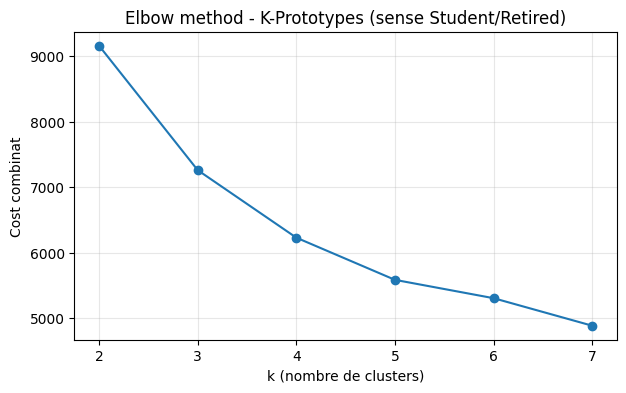

In [9]:
import matplotlib.pyplot as plt

k_range = range(2, 8)
plt.figure(figsize=(7,4))
plt.plot(k_range, costs, marker='o')
plt.xlabel('k (nombre de clusters)')
plt.ylabel('Cost combinat')
plt.title('Elbow method - K-Prototypes (sense Student/Retired)')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# 9. Model final amb k=4
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
df_rest['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)

print("Cost final:", kproto_final.cost_)
print(df_rest['cluster'].value_counts().sort_index())

Cost final: 6227.935818985677
cluster
0    2550
1    2207
2    2140
3    2626
Name: count, dtype: int64


In [11]:
# 10. Caracterització de cada cluster
for c in sorted(df_rest['cluster'].unique()):
    sub = df_rest[df_rest['cluster']==c]
    print(f"--- Cluster {c} (n={len(sub)}, {len(sub)/len(df_rest)*100:.1f}%) ---")
    print("age mean:", round(sub['age'].mean(),1), "| age median:", sub['age'].median())
    print("job_profile:", sub['job_profile'].value_counts(normalize=True).round(3).to_dict())
    print("education_label:", sub['education_label'].value_counts(normalize=True).round(3).to_dict())
    print("marital:", sub['marital'].value_counts(normalize=True).round(3).to_dict())
    print()

--- Cluster 0 (n=2550, 26.8%) ---
age mean: 53.0 | age median: 52.0
job_profile: {'White Collar': 0.595, 'Blue Collar': 0.271, 'Self-Employed': 0.08, 'Unemployed': 0.041, 'Unknown': 0.013}
education_label: {'Secondary': 0.474, 'Tertiary': 0.283, 'Primary': 0.179, 'Unknown': 0.064}
marital: {'married': 0.742, 'divorced': 0.176, 'single': 0.082}

--- Cluster 1 (n=2207, 23.2%) ---
age mean: 39.3 | age median: 40.0
job_profile: {'Blue Collar': 0.71, 'White Collar': 0.174, 'Self-Employed': 0.07, 'Unemployed': 0.039, 'Unknown': 0.008}
education_label: {'Secondary': 0.728, 'Primary': 0.22, 'Unknown': 0.04, 'Tertiary': 0.012}
marital: {'married': 0.744, 'single': 0.132, 'divorced': 0.124}

--- Cluster 2 (n=2140, 22.5%) ---
age mean: 37.0 | age median: 37.0
job_profile: {'White Collar': 0.864, 'Self-Employed': 0.088, 'Unemployed': 0.026, 'Blue Collar': 0.018, 'Unknown': 0.004}
education_label: {'Tertiary': 0.811, 'Secondary': 0.127, 'Primary': 0.032, 'Unknown': 0.03}
marital: {'married': 0.684,

In [12]:
# 11. Construir la columna 'segment' final combinant regla de negoci + clusters
df['segment'] = None
df.loc[df['job_profile']=='Student', 'segment'] = 'Student'
df.loc[df['job_profile']=='Retired', 'segment'] = 'Retired'

# Mapejar els clusters de df_rest cap a df original, usant el seu índex
df.loc[df_rest.index, 'segment'] = df_rest['cluster'].apply(lambda c: f'Cluster_{c}')

print(df['segment'].value_counts())
print()
print("Total assignat:", df['segment'].notna().sum(), "de", len(df))

segment
Cluster_3    2626
Cluster_0    2550
Cluster_1    2207
Cluster_2    2140
Retired       754
Student       353
Name: count, dtype: int64

Total assignat: 10630 de 10630


In [14]:
# Nom descriptiu de treball (provisional, pendent de validar amb Pas 2 i amb l'Elisa)
label_map = {
    'Cluster_0': 'Adults consolidats',
    'Cluster_1': 'Treballadors manuals',
    'Cluster_2': 'Professionals estudis superiors',
    'Cluster_3': 'Joves solters',
    'Retired': 'Jubilats',
    'Student': 'Estudiants'
}
df['segment_label'] = df['segment'].map(label_map)

print(df[['segment','segment_label']].drop_duplicates())

       segment                    segment_label
0    Cluster_0               Adults consolidats
2    Cluster_1             Treballadors manuals
5    Cluster_2  Professionals estudis superiors
7      Retired                         Jubilats
9    Cluster_3                    Joves solters
162    Student                       Estudiants


In [ ]:
df.to_csv('../Data/20260706_bank_dataset_clustered.csv', index=False)
print(df[['segment','segment_label']].drop_duplicates())